In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("final_alcohol.csv")

In [ ]:
df.head()

,Unnamed: 0.1,Unnamed: 0,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Type
0,0,2732,7.4,0.17,0.29,1.40,0.047,23.0,107.0,0.99390,3.52,0.65,10.4,6,White Wine
1,1,2607,5.3,0.31,0.38,10.50,0.031,53.0,140.0,0.99321,3.34,0.46,11.7,6,White Wine
2,3,3264,6.9,0.26,0.29,4.20,0.043,33.0,114.0,0.99020,3.16,0.31,12.5,6,White Wine
3,5,4859,8.4,0.32,0.35,11.70,0.029,3.0,46.0,0.99439,3.02,0.34,11.8,6,White Wine
4,6,5827,7.4,0.30,0.22,5.25,0.053,33.0,180.0,0.99260,3.13,0.45,11.6,6,White Wine


In [ ]:
df['quality'].value_counts()

,count
quality,
6,2076
5,1304
7,868
8,159
4,118
3,11
9,5


In [ ]:
df["quality"] = (df["quality"] >= 6).astype(int)

In [ ]:
df.drop('Unnamed: 0.1', axis=1, inplace=True)
df.drop('Unnamed: 0', axis=1, inplace=True)

In [ ]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Type
0,7.4,0.17,0.29,1.40,0.047,23.0,107.0,0.99390,3.52,0.65,10.4,1,White Wine
1,5.3,0.31,0.38,10.50,0.031,53.0,140.0,0.99321,3.34,0.46,11.7,1,White Wine
2,6.9,0.26,0.29,4.20,0.043,33.0,114.0,0.99020,3.16,0.31,12.5,1,White Wine
3,8.4,0.32,0.35,11.70,0.029,3.0,46.0,0.99439,3.02,0.34,11.8,1,White Wine
4,7.4,0.30,0.22,5.25,0.053,33.0,180.0,0.99260,3.13,0.45,11.6,1,White Wine


In [ ]:
x = df.drop("quality", axis=1)
y = df['quality']

In [ ]:
x.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,Type
0,7.4,0.17,0.29,1.40,0.047,23.0,107.0,0.99390,3.52,0.65,10.4,White Wine
1,5.3,0.31,0.38,10.50,0.031,53.0,140.0,0.99321,3.34,0.46,11.7,White Wine
2,6.9,0.26,0.29,4.20,0.043,33.0,114.0,0.99020,3.16,0.31,12.5,White Wine
3,8.4,0.32,0.35,11.70,0.029,3.0,46.0,0.99439,3.02,0.34,11.8,White Wine
4,7.4,0.30,0.22,5.25,0.053,33.0,180.0,0.99260,3.13,0.45,11.6,White Wine


In [ ]:
y.head()

,quality
0,1
1,1
2,1
3,1
4,1


In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.preprocessing import OneHotEncoder
enc = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
enc

OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)

In [ ]:
enc.fit(x_train[['Type']])

x_train_encoded = enc.transform(x_train[['Type']])
x_test_encoded = enc.transform(x_test[['Type']])

In [ ]:
encoded_cols = enc.get_feature_names_out(['Type'])

x_train_encoded = pd.DataFrame(x_train_encoded, columns=encoded_cols, index=x_train.index)
x_test_encoded = pd.DataFrame(x_test_encoded, columns=encoded_cols, index=x_test.index)

In [ ]:
x_train_final = pd.concat([x_train.drop(columns=['Type']), x_train_encoded], axis=1)
x_test_final = pd.concat([x_test.drop(columns=['Type']), x_test_encoded], axis=1)

KNN CLASSIFIERS

In [ ]:

from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train_final)
x_test = scaler.transform(x_test_final)

In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train, y_train)

KNeighborsClassifier()

In [ ]:
y_pred = knn.predict(x_test)

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7865786578657866

Classification Report:
               precision    recall  f1-score   support

           0       0.66      0.59      0.62       272
           1       0.83      0.87      0.85       637

    accuracy                           0.79       909
   macro avg       0.75      0.73      0.74       909
weighted avg       0.78      0.79      0.78       909



In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

Confusion Matrix:
 [[160 112]
 [ 82 555]]


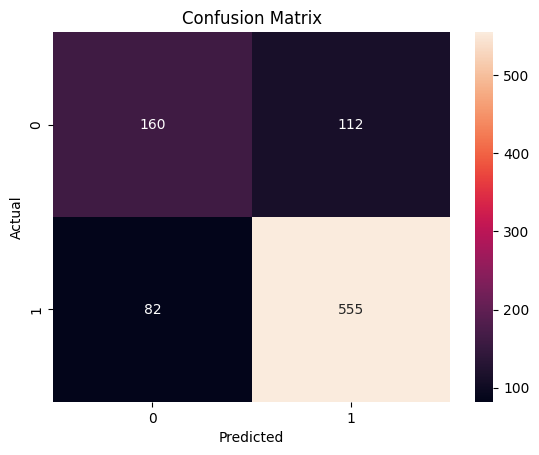

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:\n", cm)

# Plot
plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()